In [9]:
import requests
from PIL import Image

import torch
from lavis.models import load_model_and_preprocess
import os
import matplotlib.pyplot as plt 

import warnings
warnings.filterwarnings('ignore')

# Model

In [2]:
from lavis.models import model_zoo
print(model_zoo)

Architectures                  Types
albef_classification           ve
albef_feature_extractor        base
albef_nlvr                     nlvr
albef_pretrain                 base
albef_retrieval                coco, flickr
albef_vqa                      vqav2
alpro_qa                       msrvtt, msvd
alpro_retrieval                msrvtt, didemo
blip_caption                   base_coco, large_coco
blip_classification            base
blip_feature_extractor         base
blip_image_text_matching       base, large
blip_nlvr                      nlvr
blip_pretrain                  base
blip_retrieval                 coco, flickr
blip_vqa                       vqav2, okvqa, aokvqa
blip2_opt                      pretrain_opt2.7b, pretrain_opt6.7b, caption_coco_opt2.7b, caption_coco_opt6.7b
blip2_t5                       pretrain_flant5xl, pretrain_flant5xl_vitL, pretrain_flant5xxl, caption_coco_flant5xl
blip2_feature_extractor        pretrain, pretrain_vitL, coco
blip2                      

In [3]:
os.environ["CUDA_DEVICE_ORDER"]="PCI_BUS_ID"
os.environ["CUDA_VISIBLE_DEVICES"] = '4'
print (torch.cuda.device_count())

device = "cuda" if torch.cuda.is_available() else "cpu"

1


In [4]:
model, vis_processors, _ = load_model_and_preprocess(name="blip2_vicuna_instruct", model_type="vicuna7b", is_eval=True, device=device)
# model = model.float()
# model = model.to(device)

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

# Example run

In [5]:
prompt = "Describe the image in detail."

In [24]:
image_file = "http://images.cocodataset.org/val2017/000000333069.jpg"
raw_image = Image.open(requests.get(image_file, stream=True).raw)
inputs = vis_processors["eval"](raw_image).unsqueeze(0)

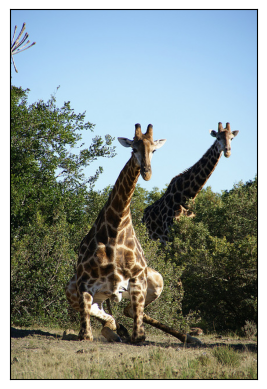

In [25]:
plt.imshow(raw_image)
plt.xticks([])
plt.yticks([])
plt.show()

In [31]:
strength = 0
model.generate({"image": inputs.to(device), "prompt": prompt}, use_nucleus_sampling=True, max_length=512)[0]

'The image features two giraffes standing in a grassy field surrounded by trees. One of the giraffes is sitting on the ground, while the other is standing next to it. Both giraffes appear to be relaxed and enjoying their surroundings. There are several trees visible in the background, adding to the natural setting of the scene.'

## Forward hook 

In [22]:
target_layer = 22
concept = None

def remind_image(target_layer):
    global concept, strength
    def hook(model, input, output):
        global concept, strength
        if (output[0].shape[1] != 1):
            concept = torch.mean(output[0], dim=1, keepdim=True)
        else:
            output = (output[0] + strength*concept, *output[1:])
        return output
    return hook


hook = model.llm_model.model.layers[target_layer].self_attn.register_forward_hook(remind_image(target_layer))

In [32]:
strength = 2
print(model.generate({"image": inputs.to(device), "prompt": prompt}, use_nucleus_sampling=True, max_length=512)[0])

The image features two giraffes standing in a grassy field surrounded by trees. One of the giraffes is sitting on the ground, while the other one is standing upright. Both giraffes have their necks stretched towards the sky, giving the impression that they are curious about their surroundings.  In addition to the two giraffes, there are several trees scattered throughout the scene. Some trees are closer to the giraffes, while others are positioned further away from them. The overall atmosphere of the scene is peaceful and relaxed, with the giraffes seemingly enjoying their time in the wild.
